# Facebook (FB) 2018 Stock Visualization

Exploratory visualization of Facebook's 2018 daily stock data, progressing from time-series charts to outlier detection, feature engineering, correlation analysis, density visualization, and regression.

**Tools:** Python · Pandas · NumPy · Matplotlib · Seaborn


## 1. Data setup

The notebook expects `data/stock_prices.csv`, indexed by trading date with open, high, low, close, and volume fields.


In [ ]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

DATA_PATH = "data/stock_prices.csv"
fb = pd.read_csv(DATA_PATH, index_col="date", parse_dates=True)
fb.head()


,open,high,low,close,volume
date,,,,,
2018-01-02,177.68,181.58,177.5500,181.42,18151903
2018-01-03,181.88,184.78,181.3300,184.67,16886563
2018-01-04,184.90,186.21,184.0996,184.33,13880896
2018-01-05,185.59,186.90,184.9300,186.85,13574535
2018-01-08,187.20,188.90,186.3300,188.28,17994726
...,...,...,...,...,...
2018-12-24,123.10,129.74,123.0200,124.06,22066002
2018-12-26,126.00,134.24,125.8900,134.18,39723370
2018-12-27,132.44,134.99,129.6700,134.52,31202509


In [ ]:
fb.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2018-01-02 to 2018-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   open    251 non-null    float64
 1   high    251 non-null    float64
 2   low     251 non-null    float64
 3   close   251 non-null    float64
 4   volume  251 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 11.8 KB


## 2. Closing-price trend

A line chart establishes the overall price trajectory. The closing price moves from $181.42 on the first trading day in the dataset to $131.09 on the final trading day, a decline of roughly 27.7% across the year.


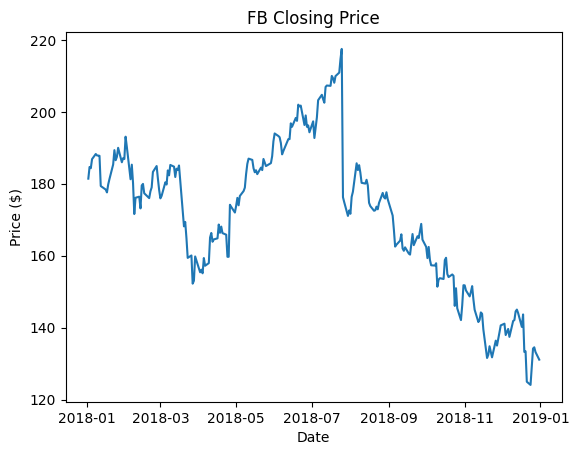

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(fb.index, fb["close"])
ax.set_title("FB Closing Price")
ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")
plt.tight_layout()
plt.show()


## 3. Comparing open, high, low, and close prices

Small multiples separate the four OHLC series so their movement can be compared without visual overlap. A combined view is also included for direct comparison.


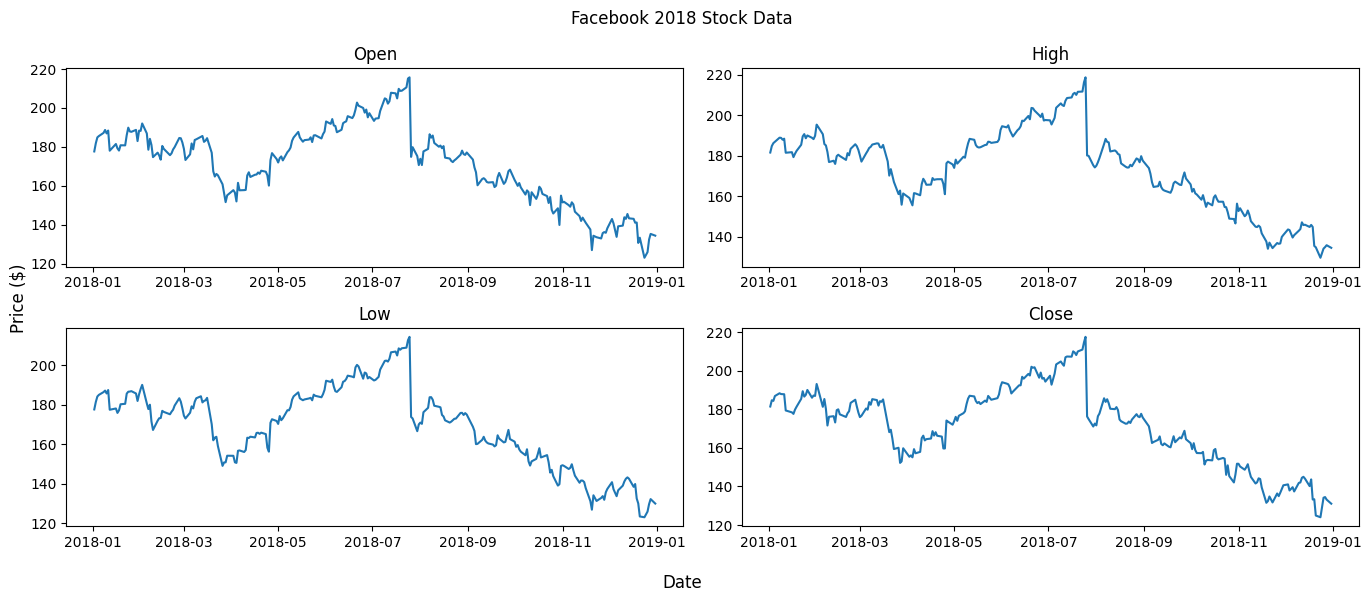

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
series = [("open", "Open"), ("high", "High"), ("low", "Low"), ("close", "Close")]

for ax, (column, title) in zip(axes.ravel(), series):
    ax.plot(fb.index, fb[column])
    ax.set_title(title)

fig.suptitle("Facebook 2018 Stock Data")
fig.supxlabel("Date")
fig.supylabel("Price ($)")
plt.tight_layout()
plt.show()


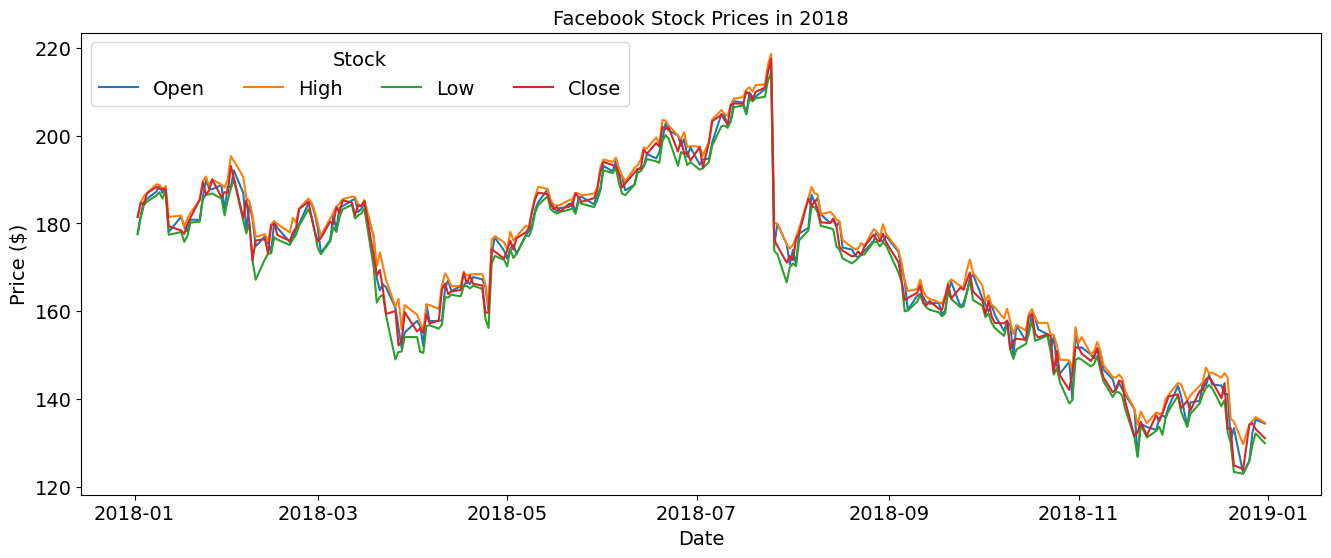

In [ ]:
plt.figure(figsize=(16, 6))
for column in ["open", "high", "low", "close"]:
    plt.plot(fb.index, fb[column], label=column.title())

plt.title("Facebook Stock Prices in 2018", fontsize=14)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Price ($)", fontsize=14)
plt.legend(loc="upper left", title="Stock", ncol=4)
plt.tight_layout()
plt.show()


## 4. Annotating a notable price move

The shaded interval marks the late-July decline. Annotation turns a basic time-series chart into a more explanatory view by connecting a visual pattern to a specific period.


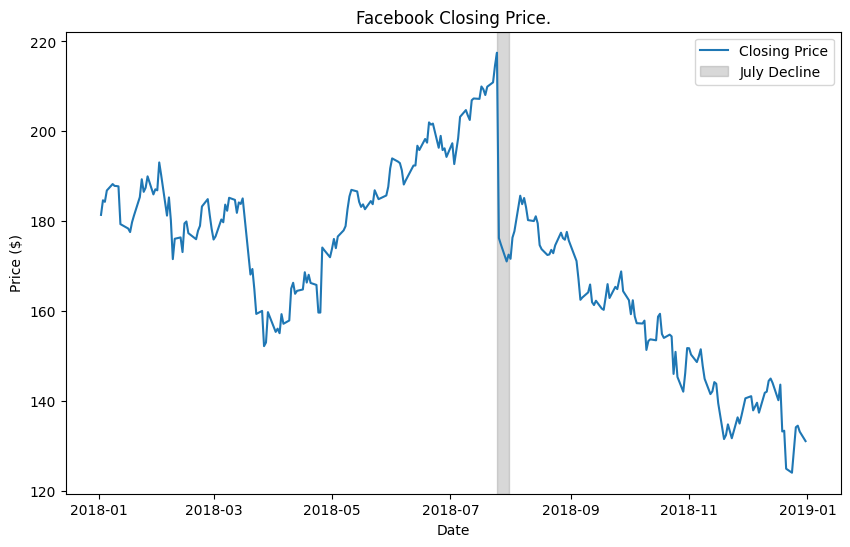

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(fb.index, fb["close"], label="Closing Price")
ax.axvspan(pd.Timestamp("2018-07-25"), pd.Timestamp("2018-07-31"),
           alpha=0.25, label="July Decline")
ax.set_title("Facebook Closing Price.")
ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")
ax.legend()
plt.tight_layout()
plt.show()


## 5. Outlier detection with Tukey fences

Tukey fences use the interquartile range (IQR) to define lower and upper bounds. Here, the method is visualized for both trading volume and closing price.


In [ ]:
outlier_data = fb[["volume", "close"]].copy()
quartiles = outlier_data.quantile([0.25, 0.75])
iqr = quartiles.loc[0.75] - quartiles.loc[0.25]

bounds = pd.DataFrame({
    "lower": quartiles.loc[0.25] - 1.5 * iqr,
    "upper": quartiles.loc[0.75] + 1.5 * iqr,
})
bounds


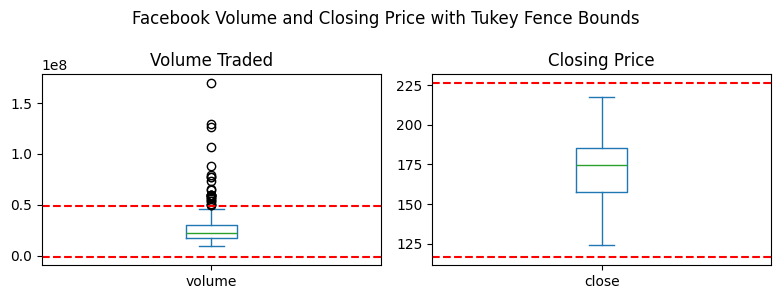

In [ ]:
axes = outlier_data.plot(
    kind="box",
    subplots=True,
    figsize=(9, 4),
    title=["Volume Traded", "Closing Price"],
)

for ax, column in zip(np.ravel(axes), outlier_data.columns):
    ax.axhline(bounds.loc[column, "lower"], linestyle="--")
    ax.axhline(bounds.loc[column, "upper"], linestyle="--")

plt.suptitle("Facebook Volume and Closing Price with Tukey Fence Bounds")
plt.tight_layout()
plt.show()


## 6. Feature engineering

Two derived features support later analysis:

- `log_volume`: log-transformed trading volume, which reduces scale skew.
- `max_abs_change`: the daily high–low range, used as a simple measure of intraday movement.

Quarter is also added as a grouping variable for multivariate plots.


In [ ]:
fb["log_volume"] = np.log(fb["volume"])
fb["max_abs_change"] = (fb["high"] - fb["low"]).abs()
fb["quarter"] = fb.index.quarter

fb[["volume", "log_volume", "high", "low", "max_abs_change", "quarter"]].head()


## 7. Correlation structure

A Pearson correlation heatmap summarizes linear relationships among the OHLC variables, volume, and engineered features.


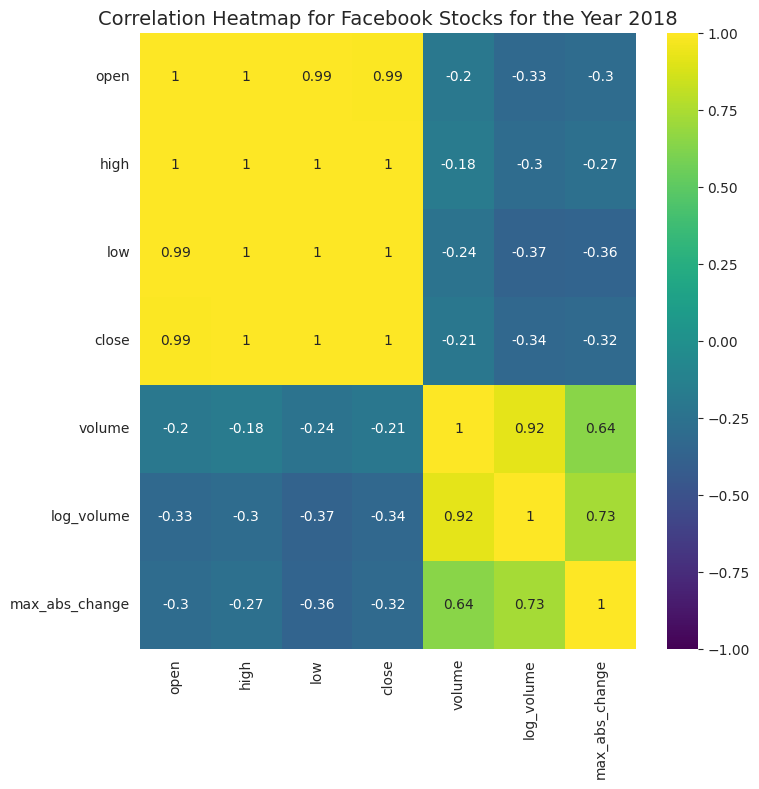

In [ ]:
plt.figure(figsize=(9, 8))
sns.heatmap(
    fb.corr(numeric_only=True),
    annot=True,
    cmap="viridis",
    vmin=-1,
    vmax=1,
    fmt=".2f",
)
plt.title("Correlation Heatmap for Facebook Stocks for the Year 2018")
plt.tight_layout()
plt.show()


## 8. Pairwise relationships by quarter

A Seaborn pairplot provides a compact multivariate view. Coloring observations by quarter helps reveal whether relationships or distributions shift through the year.


In [ ]:
pair_columns = ["open", "high", "low", "close", "log_volume", "max_abs_change", "quarter"]
pair_plot = sns.pairplot(
    data=fb[pair_columns],
    hue="quarter",
    diag_kind="kde",
    corner=True,
)
pair_plot.fig.suptitle("Pairwise Relationships in Facebook Stock Attributes", y=1.02)
plt.show()


## 9. Volume vs. intraday movement

Hexbin density handles overlapping observations better than a basic scatter plot. A regression view then summarizes the broad linear tendency between trading volume and the daily high–low range.


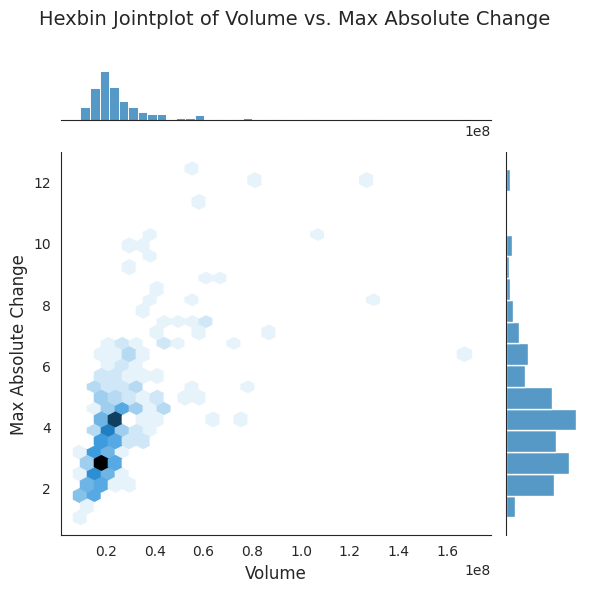

In [ ]:
sns.set_style("white")
hex_plot = sns.jointplot(
    data=fb,
    x="volume",
    y="max_abs_change",
    kind="hex",
)
hex_plot.fig.suptitle("Hexbin Jointplot of Volume vs. Max Absolute Change", y=1.02)
hex_plot.set_axis_labels("Volume", "Max Absolute Change")
plt.show()


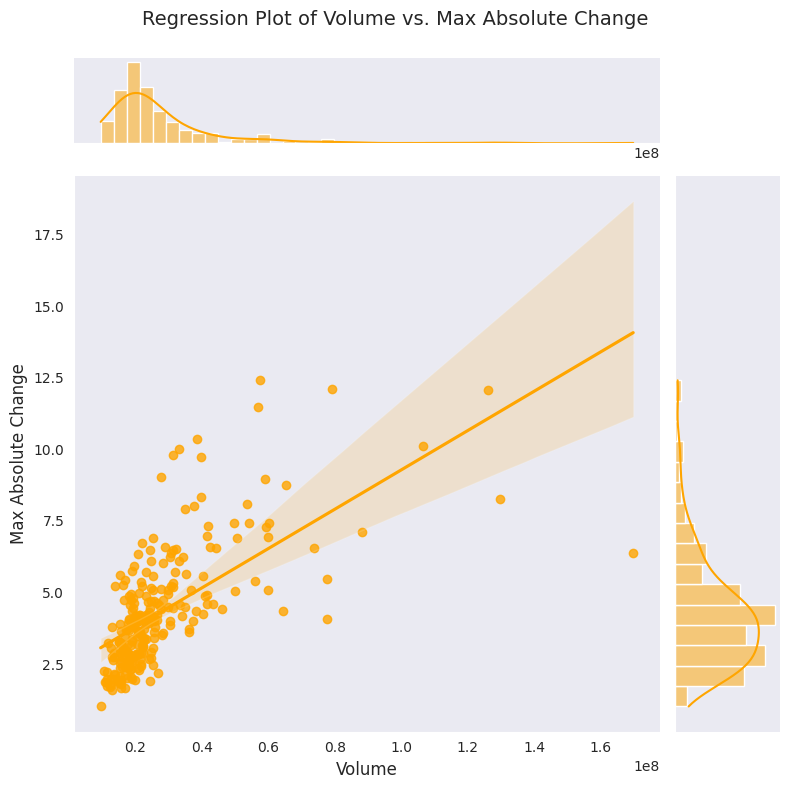

In [ ]:
sns.set_style("darkgrid")
reg_plot = sns.jointplot(
    data=fb,
    x="volume",
    y="max_abs_change",
    kind="reg",
    height=8,
)
reg_plot.fig.suptitle("Regression Plot of Volume vs. Max Absolute Change", y=1.02)
reg_plot.set_axis_labels("Volume", "Max Absolute Change")
plt.show()


## 10. Key takeaways

- The notebook moves from descriptive time-series plotting into statistical and multivariate visualization.
- Facebook's closing price fell by about 27.7% from the first to the final trading day represented in the 2018 dataset.
- The late-July period stands out visually as a major price move and is highlighted directly in the chart.
- Feature engineering makes it possible to study relationships that are not explicit in the raw OHLC data, including trading volume versus intraday price range.
